In [4]:
# %pip install -q "matplotlib>=3.7,<3.9" celluloid modula


from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch import optim

from celluloid import Camera


# 1,2,3- create and load Data to data loader for train val and test

In [38]:

# # input data and input labels:
# # X: [N, 2]
# # Y: [N]

# N = 10000
# X = 2 * torch.rand(N, 2)    # shape: [1000, 2]

# # y is just some function of x, in this case a simple binary classification problem
# Y = torch.norm(X, dim=1) < 1   # shape: [1000]

# # convert labels to class IDs first: 0 or 1
# Y = Y.long()                     # shape: [10000]

# # convert to one-hot labels
# Y = F.one_hot(Y, num_classes=2).float()  # shape: [10000, 2]


# input data and input labels:
# X: [N, 2]
# Y: [N, 2] one-hot labels

N = 10000

# sample points in [0, 2] x [0, 2]
X = 2 * torch.rand(N, 2)    # shape: [10000, 2]

x = X[:, 0]
y = X[:, 1]

# define an L-shaped region
# class 1 = inside the L
vertical_bar = (x > 0.0) & (x < 0.8) & (y > 0.3) & (y < 1.7)
horizontal_bar = (x > 0.0) & (x < 1.6) & (y > 0.0) & (y < 0.8)

Y = vertical_bar | horizontal_bar   # shape: [10000]

# convert labels to class IDs: 0 or 1
Y = Y.long()                        # shape: [10000]

# convert to one-hot labels
Y = F.one_hot(Y, num_classes=2).float()  # shape: [10000, 2]



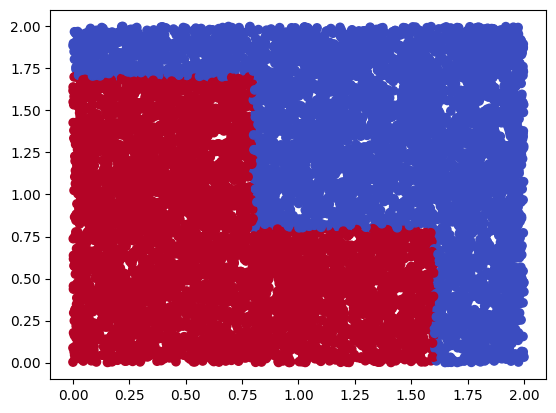

In [39]:
plt.scatter(X[:, 0], X[:, 1], c=Y[:, 1], cmap='coolwarm')

In [33]:
# convert data to tensor dataset
TensorDataset = torch.utils.data.TensorDataset(X, Y)
# split data into train, val, test
D_train,D_val, D_test = torch.utils.data.random_split(TensorDataset, [int(0.8*N), int(0.1*N), int(0.1*N)])
# create data loaders for train, val, test
train_loader = torch.utils.data.DataLoader(D_train, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(D_val, batch_size=128, shuffle=False)
test_loader = torch.utils.data.DataLoader(D_test, batch_size=128, shuffle=False)

# check the shape of the data
for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([128, 2]) torch.Size([128, 2])


# 4 - define a simple MLP for demostration

In [34]:
class simple_MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=2, output_dim=2):
        super().__init__()

        #defining the layers of the MLP and the last layer is a softmax to get probabilities for the two classes
        self.layers = nn.ModuleList( [
        nn.Linear(input_dim, hidden_dim, bias=True),
        nn.LeakyReLU(),
        nn.Linear(hidden_dim, hidden_dim, bias=True),
        nn.LeakyReLU(),
        nn.Linear(hidden_dim, output_dim, bias=True),
        nn.Softmax(dim=1)
        ] ) 

        self.layer_names = ['linear1', 'relu1', 'linear2', 'relu2', 'linear3', 'softmax']

    # the forward function takes an input x and passes it through the layers of the MLP, and returns the output of the last layer. It also returns the activations of each layer if return_activations is True.
    def forward(self, x,return_activations=False):
        activations = {} # initiallt empty dictionary to store the activations of each layer
        for layer, name in zip(self.layers, self.layer_names):
            x = layer(x)
            activations[name] = x

        # when the transofration is done, we return the output of the last layer and the activations of each layer if return_activations is True, otherwise we just return the output of the last layer.    
        if return_activations:
            return x, activations
        else:
            return x
        



        

In [30]:
def identity_init_for_2d_visualization(model):
        for layer in model.layers:
            if isinstance(layer, nn.Linear):
                with torch.no_grad():
                    layer.weight.zero_()
                    layer.bias.zero_()

                    # Put identity in the overlapping part of the matrix
                    dim = min(layer.weight.shape[0], layer.weight.shape[1])
                    layer.weight[:dim, :dim] = torch.eye(dim)

In [8]:
# create an instance of the MLP
model = simple_MLP(input_dim=2, hidden_dim=2, output_dim=2)

# 5- define a loss function

In [12]:
criterion= nn.BCELoss()  # binary cross entropy loss for binary classification

# 6 define the train/val/test functions

In [9]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs=100):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()

            # outputs are softmax probabilities: [batch_size, 2]
            outputs = model(x_batch)

            # y_batch should be one-hot labels: [batch_size, 2]
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # evaluate on validation set
        model.eval()
        val_running_loss = 0.0

        with torch.no_grad():
            for x_val, y_val in val_loader:
                val_outputs = model(x_val)

                # no squeeze here either
                val_loss = criterion(val_outputs, y_val)

                val_running_loss += val_loss.item() * x_val.size(0)

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)

        print(
            f"Epoch {epoch+1}/{num_epochs}, "
            f"Train Loss: {epoch_loss:.4f}, "
            f"Val Loss: {val_epoch_loss:.4f}"
        )

    return train_losses, val_losses

In [13]:
def test(model, test_loader, criterion):
    model.eval()

    test_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_test, y_test in test_loader:
            # model output: [batch_size, 2], softmax probabilities
            test_outputs = model(x_test)

            # y_test: [batch_size, 2], one-hot labels
            test_loss = criterion(test_outputs, y_test)

            test_running_loss += test_loss.item() * x_test.size(0)

            # predicted class: 0 or 1
            preds = torch.argmax(test_outputs, dim=1)

            # true class: convert one-hot back to class labels
            true_labels = torch.argmax(y_test, dim=1)

            correct += (preds == true_labels).sum().item()
            total += y_test.size(0)

    test_epoch_loss = test_running_loss / len(test_loader.dataset)
    test_acc = correct / total

    print(f"Test Loss: {test_epoch_loss:.4f}, Test Acc: {test_acc:.4f}")

# 7 define training loop and run the training

In [21]:
# create an instance of the MLP
model = simple_MLP(input_dim=2, hidden_dim=2, output_dim=2)
identity_init_for_2d_visualization(model)

optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses, val_losses = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)
test_loss = test(model, test_loader, criterion)

Epoch 1/10, Train Loss: 0.5272, Val Loss: 0.3720
Epoch 2/10, Train Loss: 0.2966, Val Loss: 0.2387
Epoch 3/10, Train Loss: 0.2238, Val Loss: 0.2121
Epoch 4/10, Train Loss: 0.2085, Val Loss: 0.2095
Epoch 5/10, Train Loss: 0.2075, Val Loss: 0.2063
Epoch 6/10, Train Loss: 0.2058, Val Loss: 0.2054
Epoch 7/10, Train Loss: 0.2057, Val Loss: 0.2061
Epoch 8/10, Train Loss: 0.2072, Val Loss: 0.2063
Epoch 9/10, Train Loss: 0.2049, Val Loss: 0.2065
Epoch 10/10, Train Loss: 0.2089, Val Loss: 0.2072
Test Loss: 0.2065, Test Acc: 0.9030


# 8 visulization of the Representation learning


In [40]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors


def plot_layerwise_representations(
    model,
    X,
    y=None,
    max_lines=250,
    plane_gap=3.0,
    plane_alpha=0.30,
    plane_lim=1.0,
    pad_frac=0.08,
    seed=0,
):
    """
    Plot the input and every intermediate 2D representation of the model
    on stacked planes in 3D.

    Important behavior
    ------------------
    Each plane has the SAME visual size: [-plane_lim, plane_lim] x [-plane_lim, plane_lim].

    But each layer's points are shifted and scaled locally so they spread across
    the full plane. This makes every representation visually readable.

    This means absolute scale is NOT preserved across layers.
    The plot shows geometry/pattern within each layer, not raw coordinate size.

    Parameters
    ----------
    model : nn.Module
        Must support forward(x, return_activations=True).

    X : torch.Tensor
        Shape [N, 2].

    y : torch.Tensor or None
        Optional coloring labels. Can be shape [N], or one-hot [N, n_classes].

    max_lines : int
        Number of point-to-point mapping lines to draw between consecutive planes.

    plane_gap : float
        Distance between stacked planes.

    plane_alpha : float
        Alpha for plane surfaces.

    plane_lim : float
        Visual half-width of every plane.
        Every plane is drawn from -plane_lim to +plane_lim.

    pad_frac : float
        Padding around each layer's points before scaling.

    seed : int
        Random seed for selecting mapping lines.
    """

    # --------------------------------------------------
    # 1) Collect model activations
    # --------------------------------------------------
    model.eval()

    with torch.no_grad():
        _, activations = model(X, return_activations=True)

    # Ordered representations: input first, then each layer output
    reps = [("input", X)]
    for name in model.layer_names:
        reps.append((name, activations[name]))

    # Convert all representations to numpy and check dimensionality
    reps_np_raw = []

    for name, tensor in reps:
        arr = tensor.detach().cpu().numpy()

        if arr.ndim != 2 or arr.shape[1] != 2:
            raise ValueError(f"Layer '{name}' is not 2D. Got shape {arr.shape}.")

        reps_np_raw.append((name, arr))

    N = X.shape[0]

    # --------------------------------------------------
    # 2) Handle point colors
    # --------------------------------------------------
    point_colors = "gray"
    line_colors = np.tile(np.array([[0.5, 0.5, 0.5, 1.0]]), (N, 1))

    if y is not None:
        y_np = y.detach().cpu().numpy()

        if y_np.ndim == 2:
            # one-hot or probability labels -> class index
            y_np = np.argmax(y_np, axis=1)

        cmap_name = "coolwarm"
        cmap_obj = plt.get_cmap(cmap_name)

        if np.min(y_np) == np.max(y_np):
            rgba = np.tile(cmap_obj(0.5), (len(y_np), 1))
        else:
            norm = mcolors.Normalize(vmin=np.min(y_np), vmax=np.max(y_np))
            rgba = cmap_obj(norm(y_np))

        point_colors = rgba
        line_colors = rgba

    # --------------------------------------------------
    # 3) Normalize each layer to the same visual plane size
    # --------------------------------------------------
    def scale_layer_to_plane(arr, plane_lim=1.0, pad_frac=0.08):
        """
        Shift and scale one 2D representation so it fits inside
        [-plane_lim, plane_lim] x [-plane_lim, plane_lim].

        The same scale is used for x and y to preserve local geometry.
        """

        x_min, x_max = np.min(arr[:, 0]), np.max(arr[:, 0])
        y_min, y_max = np.min(arr[:, 1]), np.max(arr[:, 1])

        x_center = 0.5 * (x_min + x_max)
        y_center = 0.5 * (y_min + y_max)

        x_half = 0.5 * (x_max - x_min)
        y_half = 0.5 * (y_max - y_min)

        # Use one scale for both axes so local geometry is not distorted
        half = max(x_half, y_half)

        # Avoid division by zero if points collapse to one location
        half = max(half, 1e-8)

        # Add padding so points are not exactly on the border
        half = half * (1.0 + pad_frac)

        arr_scaled = arr.copy()
        arr_scaled[:, 0] = (arr[:, 0] - x_center) / half * plane_lim
        arr_scaled[:, 1] = (arr[:, 1] - y_center) / half * plane_lim

        local_info = {
            "x_center": x_center,
            "y_center": y_center,
            "scale": half,
            "x_raw_lim": (x_center - half, x_center + half),
            "y_raw_lim": (y_center - half, y_center + half),
        }

        return arr_scaled, local_info

    reps_np = []
    local_infos = []

    for name, arr in reps_np_raw:
        arr_scaled, local_info = scale_layer_to_plane(
            arr,
            plane_lim=plane_lim,
            pad_frac=pad_frac,
        )

        reps_np.append((name, arr_scaled))
        local_infos.append(local_info)

    # --------------------------------------------------
    # 4) Create figure
    # --------------------------------------------------
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.set_proj_type("ortho")
    ax.view_init(elev=25, azim=135)

    # Same plane grid for every layer
    grid = np.linspace(-plane_lim, plane_lim, 20)
    U, V = np.meshgrid(grid, grid)

    # z positions for planes
    z_positions = [i * plane_gap for i in range(len(reps_np))]

    # --------------------------------------------------
    # 5) Draw planes and points
    # --------------------------------------------------
    for k, ((name, arr), z) in enumerate(zip(reps_np, z_positions)):
        Z = np.zeros_like(U) + z

        # Gray plane
        ax.plot_surface(
            U,
            V,
            Z,
            color="lightgray",
            alpha=plane_alpha,
            linewidth=0,
            shade=False,
        )

        # Black square border
        ax.plot(
            [-plane_lim, plane_lim],
            [-plane_lim, -plane_lim],
            [z, z],
            color="black",
            linewidth=1.2,
        )
        ax.plot(
            [-plane_lim, plane_lim],
            [plane_lim, plane_lim],
            [z, z],
            color="black",
            linewidth=1.2,
        )
        ax.plot(
            [-plane_lim, -plane_lim],
            [-plane_lim, plane_lim],
            [z, z],
            color="black",
            linewidth=1.2,
        )
        ax.plot(
            [plane_lim, plane_lim],
            [-plane_lim, plane_lim],
            [z, z],
            color="black",
            linewidth=1.2,
        )

        # Points
        ax.scatter(
            arr[:, 0],
            arr[:, 1],
            np.full(arr.shape[0], z),
            s=10,
            c=point_colors,
            alpha=0.8,
            depthshade=False,
        )

        # Plane label
        ax.text(
            -1.15 * plane_lim,
            1.15 * plane_lim,
            z,
            name,
            fontsize=9,
        )

    # --------------------------------------------------
    # 6) Draw mapping lines between consecutive planes
    # --------------------------------------------------
    rng = np.random.default_rng(seed)

    n_lines = min(max_lines, N)
    idx = rng.choice(N, size=n_lines, replace=False)

    for i in idx:
        for j in range(len(reps_np) - 1):
            arr1 = reps_np[j][1]
            arr2 = reps_np[j + 1][1]

            z1 = z_positions[j]
            z2 = z_positions[j + 1]

            ax.plot(
                [arr1[i, 0], arr2[i, 0]],
                [arr1[i, 1], arr2[i, 1]],
                [z1, z2],
                "--",
                alpha=0.30,
                linewidth=0.8,
                c=line_colors[i],
            )

    # --------------------------------------------------
    # 7) Axis formatting
    # --------------------------------------------------
    ax.set_xlim(-1.2 * plane_lim, 1.2 * plane_lim)
    ax.set_ylim(-1.2 * plane_lim, 1.2 * plane_lim)
    ax.set_zlim(0, z_positions[-1] + 0.5)

    ax.set_xticks([-plane_lim, 0, plane_lim])
    ax.set_yticks([-plane_lim, 0, plane_lim])

    ax.set_xlabel("local x1")
    ax.set_ylabel("local x2")
    ax.set_box_aspect((1, 1, 1.2))

    # Remove panes / grid / z-axis clutter
    ax.grid(False)
    ax.set_zticks([])
    ax.set_zlabel("")

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.xaxis.line.set_alpha(0)
    ax.yaxis.line.set_alpha(0)
    ax.zaxis.line.set_alpha(0)

    # Keep your preferred orientation
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

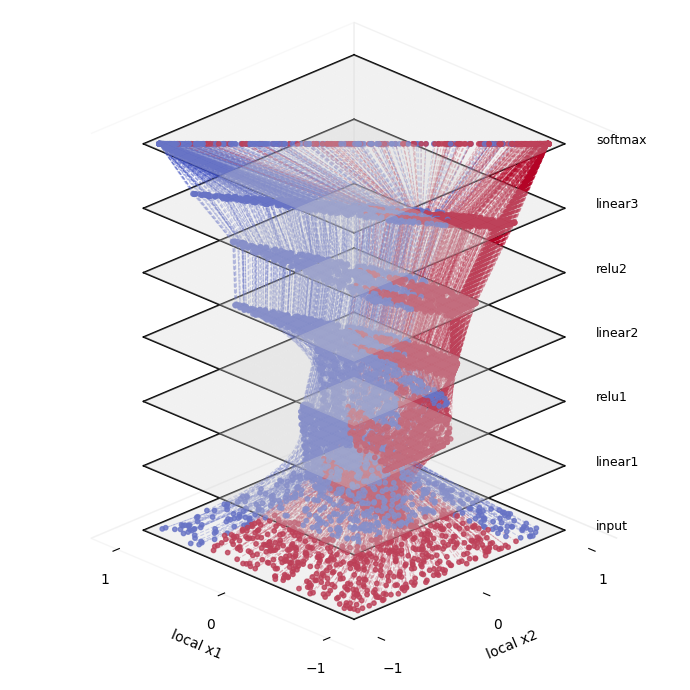

In [41]:
N_vis = 1000
idx_vis = torch.randperm(N)[:N_vis]

X_vis = X[idx_vis]
Y_vis = Y[idx_vis]   # Y is already one-hot

plot_layerwise_representations(
    model,
    X_vis,
    y=Y_vis,
    max_lines=N_vis,
    plane_gap=15.0
)